# Análisis de Datos

## Variables

* ***¿Qué es una variable en estadística?***
  - Una variable es cualquier característica que puede cambiar entre observaciones.
* ***Tipos de variables***
  - Variables Cualitativas (Categóricas).
  - Variables Cuantitativas (Numéricas).
* ***Categóricas***
* Describen cualidades, no cantidades numéricas medibles.
  - `Nominales (sin orden)`: No hay jerarquía entre valores. (colores, Cuidad, Género, No se puede decir que uno es mayor que otro).
  - `Ordinales (con orden)`: Sí hay jerarquía, pero no sabes la distancia entre niveles. (Satisfacción, Rangos, Nivel Atención).
* ***Numéricas***
  - `Discretas`: Valores contables (normalmente enteros). (Números de hijos, número de compras o errores).
  - `Continuas`: Valores medibles en una escala continua. (Tiempo, Peso, Temperatura).
* ***Que algo tenga números NO significa que sea cuantitativo***.
* Código postal → es número, pero es categórico nominal.
* Si en la vida real puede medirse con decimales → es continua, como la edad.

## Distribuciones

* ***¿Qué es una distribución?***
  - Una distribución es: cómo se reparten los valores de una variable y con qué frecuencia ocurren.
* ***Dos formas de entender una distribución***
* ***Empírica (datos reales)***
* Es la que obtienes de un dataset:
  - Histogramas.
  - Conteos.
  - Gráficos.
* Es lo que haces en Data Science normalmente.
* ***Teórica (modelos matemáticos)***
* Son funciones ideales que describen cómo deberían comportarse los datos:
  - Normal.
  - Binomial.
  - Poisson.
  - Exponencial
* Estas son “formas ideales”
* ***Tipos de distribuciones (las importantes)***
* ***Distribución Normal***
  - Forma de campana.
  - Simétrica.
  - Media = mediana = moda.
* ***Distribuciones Sesgadas (Skewed)***
  - Sesgo positivo (derecha).
  - Cola hacia la derecha.
  - Muchos valores pequeños, pocos muy grandes.
  - Por ejemplo los ingresos de una serie de personas.
  - Sesgo negativo (izquierda).
  - Cola hacia la izquierda.
  - Muchos valores grandes, pocos muy pequeños
* ***Distribución Uniforme***
  - Todos los valores tienen la misma probabilidad.
  - Ejemplo: un dado justo.
* ***Distribuciones discretas***
  - Binomial → número de éxitos en n intentos.
  - Poisson → número de eventos en un intervalo.

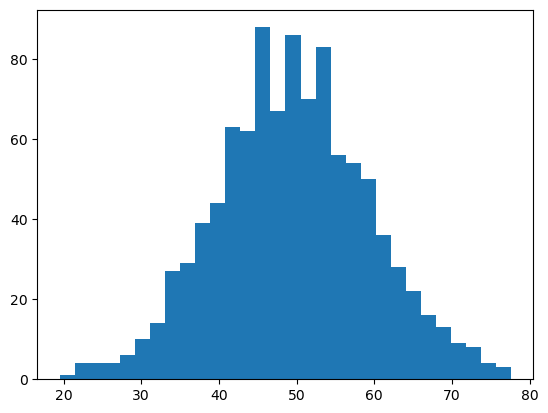

49.54743292509804
49.41971965200372


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Fijamos la muestra
np.random.seed(0)

### Media 50, desviación de 10, muestra de 1000
data = np.random.normal(loc=50, scale=10, size=1000)

plt.hist(data, bins=30)
plt.show()

print(np.mean(data))
print(np.median(data))

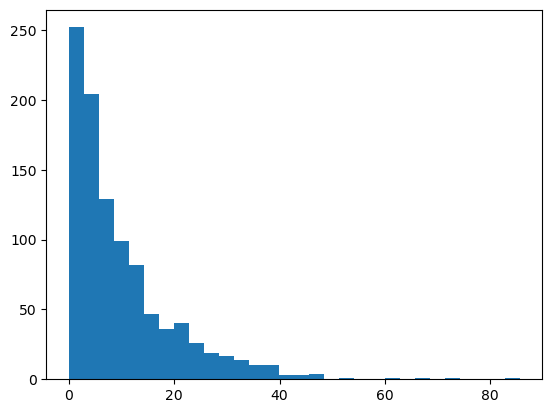

10.035402087607089
6.564760596181182


In [2]:
np.random.seed(0)
data = np.random.exponential(scale=10, size=1000)

plt.hist(data, bins=30)
plt.show()

print(np.mean(data))
print(np.median(data))

## ¿Cómo saber qué distribución siguen tus datos?

* `Kernel Density Estimation`.
* Es una técnica estadística que sirve para estimar la forma de la distribución de un conjunto de datos de manera suave y continua.
* El `KDE` como probabilidad, imagina que dejas caer una moneda al azar sobre tu gráfico:
  - Áreas altas: Si la curva es alta en un punto $x$, significa que hay una mayor probabilidad de encontrar datos ahí.
  - Áreas bajas: Si la curva está cerca de cero, es poco probable que aparezca un valor en esa zona.
* Técnicamente, el `KDE` no te da la probabilidad exacta de un punto (porque en distribuciones continuas la probabilidad de un punto exacto es siempre 0), sino que te da la densidad:
  - El área es la clave: Si quieres saber qué tan probable es que un valor caiga entre el punto $A$ y el punto $B$, calculas el área bajo la curva entre esos dos límites.
  - Predicción: Se usa para "adivinar" dónde caerán futuros puntos basándose en los que ya observaste.

<Axes: ylabel='Density'>

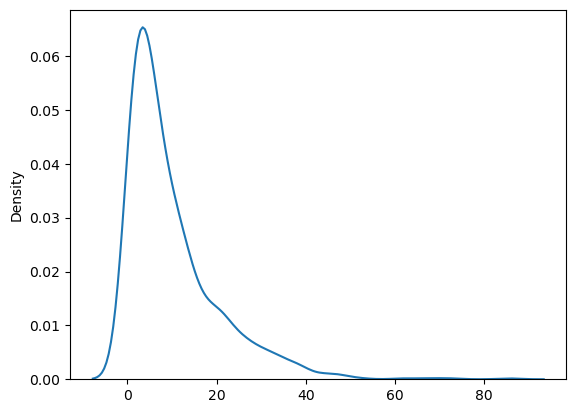

In [3]:
import seaborn as sns
sns.kdeplot(data)

* Los `QQ plots` son de esas herramientas que separan a alguien que “grafica” de alguien que analiza distribuciones en serio.
* `QQ` = ***Quantile–Quantile plot***.
* Es un gráfico que compara: los cuantiles de tus datos vs los cuantiles de una distribución teórica (normal, por ejemplo).
* Es un simple: ***¿Mis datos se comportan como una distribución normal?***.
* Un cuantil es básicamente: el valor por debajo del cual cae cierto porcentaje de datos,
* Ejemplos:
  - `50%` → mediana.
  - `25%` → primer cuartil.
  - `75%` → tercer cuartil.
* ***¿Qué hace el QQ plot?***
  - Ordena tus datos.
  - Toma los cuantiles de tus datos.
  - Toma los cuantiles de una normal teórica.
  - Los compara punto a punto.
* ***Interpretación***
* Si los puntos caen en una línea recta: Tus datos siguen una distribución normal en este caso.
* Si se desvían, depende de cómo se desvían:
  - Forma `S` hacia arriba es sesgo positivo.
  - Forma `S` hacia abajo es sesgo negativo.
  - Colas Separas indica outliers o colas pesadas.
  - Mucha dispersión no es normal.
| Tipo de distribución | QQ plot (izquierda) | QQ plot (derecha) |
| -------------------- | ------------------- | ----------------- |
| Normal               | Línea recta         | Línea recta       |
| Sesgo positivo       | Abajo               | Arriba            |
| Sesgo negativo       | Arriba              | Abajo             |

* Al usar una distribución exponencial y compararla contra una normal `(dist="norm")`, no verás una `"S"`, sino una curva pronunciada hacia arriba.
* Esto sucede porque la distribución exponencial es asimétrica y no tiene valores negativos, mientras que la normal es simétrica.
* ***¿Por qué ves esa curva?***
  - Asimetría a la derecha: La exponencial tiene una "cola" muy larga hacia los valores positivos.
  - En el gráfico, verás que los puntos del lado derecho se disparan hacia arriba, alejándose de la línea roja.
  - Límite en cero: Como la exponencial no tiene valores menores a cero, la parte izquierda del gráfico se "aplana" o corta bruscamente en comparación con la cola izquierda de la normal (que llega a $-\infty$.
  - Falta de "S": La forma de "S" aparece cuando comparas distribuciones que son ambas simétricas pero con diferente grosor en las colas (como una t-Student vs Normal). Al ser la exponencial totalmente asimétrica, genera una curva simple.

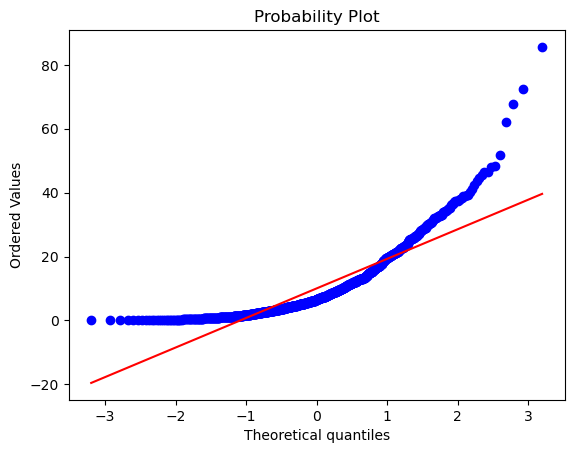

In [4]:
import scipy.stats as stats
stats.probplot(data, dist="norm", plot=plt)
plt.show()

## Transformaciones de datos (log, sqrt, etc.).

* ***Distribución Simétrica***
  - En una distribución simétrica (como la normal), la moda=mediana=media tienden a ser la punta de la campana.
* ***Distribución Sesgada Positivamente (a la izquierda)***
  - Es como una montaña rusa, que empieza en un máximo y empieza a caer.
  - Aquí se sigue lo siguiente: Moda < Mediana < Media.
* ***Distribución Sesgada negativamente (a la derecha)***
  - Es como una montaña rusa, que empieza en un minimo y empieza a subir.
  - Aquí se sigue lo siguiente: Moda > Mediana > Media.

* Las transformaciones de datos son una herramienta muy importante en estadística y análisis de datos porque ayudan a:
  - Hacer distribuciones más “normales”.
  - Reducir asimetría.
  - Estabilizar varianza.
  - Mejorar modelos estadísticos.
  - Facilitar interpretación.
* ***¿Qué es una transformación?***
* Una transformación toma tus datos originales y les aplica una función matemática.
* Por ejemplo, `x = [1, 10, 100, 1000]` aplicarles logaritmo y tener `x = [0, 1, 2, 3]`.
* ***¿Por qué se usan?***
* Muchos métodos estadísticos asumen:
  - Distribución aproximadamente normal.
  - Varianza constante.
  - Ausencia de valores extremadamente sesgados.
* Pero en la vida real aparecen datos como: *salarios, precios, población, tiempos, ventas, ingresos*.
* Estos suelen tener: *cola larga, outliers, crecimiento exponencial*.
* ***Las transformaciones ayudan a “domar” esos problemas***.
* Empcemos por la ***Transformación Logarítmica***: $y=Log(x)$ o `np.log(x)`.
* ¿Cuándo usarla?
  - Cuando hay crecimiento exponencial.
  - Hay datos muy sesgados a la derecha.
  - Cuando se tienen grandes diferencias de escala.
* Ejemplo: Imagina que tienes estos ingresos `Ingresos:[1000, 1200, 1500, 2000, 50000]`, el 5000 atrae todo.
* Entonces pasa de ser esto a esto:
```css
|
|     *
|    *
|   *
| *
|________________ 

|   *  *  *  *
| *  *  *  *
|________________
```
* Ahora revisemos la ***Transformación Raíz Cuadrada***: $y=\sqrt{x}$ o `np.sqrt(x)`.
* ¿Cuándo usarla?
  - Conteos.
  - Datos Poisson.
  - Moderada asimetría.
* ***Reduce diferencias grandes, pero menos agresivamente que el log***.
* Finalmente está la ***Transformación Cuadrática***: $y=x^2$ o `x**2`.
* ***¿Para qué sirve?***
  - Enfatizar diferencias.
  - Relaciones no lineales.
  - Ingeniería de características.
* Bonus: ***Transformación Reciproca***: $y=\frac{1}{x}$
* Se usa cuando cuando valores grandes deben comprimirse mucho.
* Por ejemplo, imagina que tenemos esto `x = [1, 10, 100, 1000]`.
| Transformación | Resultado           |
| -------------- | ------------------- |
| Original       | 1, 10, 100, 1000    |
| sqrt           | 1, 3.16, 10, 31.6   |
| log            | 0, 2.3, 4.6, 6.9    |
| reciprocal     | 1, 0.1, 0.01, 0.001 |

* ***Cómo decidir qué transformación usar***
| Problema                 | Transformación |
| ------------------------ | -------------- |
| Ligera asimetría         | sqrt           |
| Fuerte asimetría         | log            |
| Crecimiento exponencial  | log            |
| Conteos                  | sqrt           |
| Valores enormes extremos | reciprocal     |
| Relaciones no lineales   | potencia       |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.exponential(scale=50, size=1000)

transformaciones = {
    "Original": x,
    "Log": np.log1p(x),
    "Sqrt": np.sqrt(x)
}

for nombre, datos in transformaciones.items():
    plt.figure()
    plt.hist(datos, bins=30)
    plt.title(nombre)

plt.show()

In [ ]:
from scipy.stats import skew
y = np.log1p(x)
print(skew(x))
print(skew(y))

from scipy import stats

stats.probplot(y, dist="norm", plot=plt)
plt.show()

from scipy.stats import boxcox

y, lam = boxcox(x)

* En resumen:
  - Reduce las distancias, especialmente entre valores grandes.
  - Reducir el impacto de valores extremos y del sesgo.
  - La distribución se vuelve más simétrica, puede hacer que la media y mediana serían más cercanas.
* Recuerda:
* En distribuciones sesgadas:
  - La media se “jala” hacia la cola
  - Si comprimes la cola: la media deja de desplazarse tanto
* Entonces: media ≈ mediana nuevamente.
| Distribución   | Relación media vs mediana |
| -------------- | ------------------------- |
| Simétrica      | media ≈ mediana           |
| Sesgo positivo | media > mediana           |
| Sesgo negativo | media < mediana           |


## Test Shapiro-Wilk

* El `QQ Plot` es el análisis visual (***subjetivo***) y la Prueba de Shapiro-Wilk es el análisis estadístico (***objetivo***) para determinar la normalidad de tus datos.
* El `QQ Plot` te da el contexto: Si Shapiro-Wilk dice que tus datos no son normales, el `QQ Plot` te muestra si es porque tienes valores atípicos, si los datos están sesgados o si las colas son muy pesadas.
* Interpretación:
  - p > 0.05 → no puedes rechazar que sea normal.
  - p < 0.05 → NO es normal.
* `np.log(data)` reduce sesgo y colas.

In [8]:
import scipy.stats as stats
import numpy as np

data = np.random.exponential(scale=10, size=1000)

# Prueba de Shapiro-Wilk
stat, p_value = stats.shapiro(data)

print(f"Estadístico: {stat:.4f}, p-value: {p_value:.4f}")

if p_value > 0.05:
    print("No se rechaza la hipótesis nula (Parece Normal)")
else:
    print("Se rechaza la hipótesis nula (No es Normal)")

Estadístico: 0.8289, p-value: 0.0000
Se rechaza la hipótesis nula (No es Normal)
